# LSTM with GloVe 6B 100d - Synthetic Data

This notebook trains a LSTM model to classify a news article into one of five bias labels using GloVe embeddings for each word in each article. Crucially, this model uses the original real world data plus **synthetically generated data** as the training set. The test set remains the same. 

We utilised chatgpt to generate additional samples for the under represented classess through zero shot prompting. 

## Import

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader           

from collections import Counter
from itertools import cycle
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_class_weight

import skorch
from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from skorch.helper import predefined_split

from functools import partial

# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

glove_file = 'glove.6B/glove.6B.100d.txt'
if not os.path.exists(glove_file):
    raise FileNotFoundError(f"{glove_file} not found. Please download it from https://nlp.stanford.edu/projects/glove/ and place it in your working directory.")

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We chose GloVe over word2vec as the pretrained model has larger vocab more robust, more reasons why here, over us training our own word2vec embedding with our limited sample of n<5000 

We chose the 6B model with 100 dimensions as we are running our models on local and our compute power is limited. 

In [3]:
# Load preprocessed data
train = pd.read_csv('data/synthetic_transformers_train_preprocessed.csv')
test = pd.read_csv('data/transformers_test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Encode labels
y_train_raw = train['Bias']
y_test_raw = test['Bias']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

Number of classes: 5


In [4]:
# check 
train.head(5)

,Title,cleaned_text,Bias
0,Industry Leaders Debate Tax Cuts Amid Rising C...,Experts economic highlights growth report with...,right
1,Analysts Debate Free Markets As Experts Weigh In,Competition issues ongoing about policy concer...,right
2,Researchers Highlight Deregulation Sparking De...,Ongoing believe report responsibility environm...,right
3,Industry Leaders Debate Free Markets After Com...,Aims could key believe shows while believe com...,right
4,Government Highlight Economic Freedom In Lates...,New importance engagement policy individual li...,right


In [33]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5422 entries, 0 to 5421
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         5422 non-null   object
 1   cleaned_text  5422 non-null   object
 2   Bias          5422 non-null   object
dtypes: object(3)
memory usage: 127.2+ KB


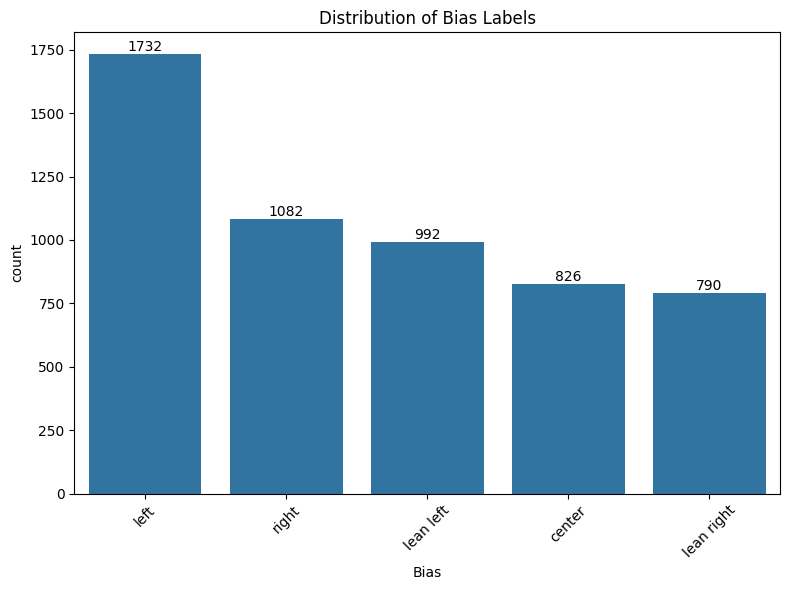

In [34]:
# Visualizing the distribution of Bias labels
plt.figure(figsize=(8,6))
ax = sns.countplot(data=train, x='Bias', order=train['Bias'].value_counts().index)
plt.title('Distribution of Bias Labels')
plt.xticks(rotation=45)

# Add count labels using bar_label
plt.bar_label(ax.containers[0])

plt.tight_layout()
plt.show()

## Global Variables

In [5]:
batch_size = 32
criterion = nn.CrossEntropyLoss()
torch.manual_seed(42)
np.random.seed(42)

## Build Vocab and Embeddings

In [6]:
def tokenize(text):
    return text.lower().split()
    
def build_vocab(texts):
    vocab = Counter()
    for text in texts:
        tokens = tokenize(text)
        vocab.update(tokens)
    return vocab

def load_glove_embeddings(glove_file, vocab, embedding_dim):
    embeddings_index = {}
    with open(glove_file, 'r', encoding='utf8') as f:
        for line in f:
            parts = line.strip().split()
            # skip any malformed lines
            if len(parts) != embedding_dim + 1:
                continue
            word = parts[0]
            vector = np.asarray(parts[1:], dtype=np.float32)
            embeddings_index[word] = vector

    # Special tokens
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    pad_vec = np.zeros(embedding_dim, dtype=np.float32)
    unk_vec = np.random.normal(scale=0.6, size=(embedding_dim,)).astype(np.float32)

    # Build list of vectors
    embedding_list = [pad_vec, unk_vec]
    for word in sorted(vocab):
        word2idx[word] = len(word2idx)
        vec = embeddings_index.get(word)
        if vec is None:
            vec = np.random.normal(scale=0.6, size=(embedding_dim,)).astype(np.float32)
        embedding_list.append(vec)

    embedding_matrix = np.asarray(embedding_list, dtype=np.float32)  
    print("Embedding matrix shape:", embedding_matrix.shape)
    embedding_tensor = torch.from_numpy(embedding_matrix)      

    return word2idx, embedding_tensor, embeddings_index


We use simple white space tokenizer to use with GloVe which is word based to feed words sequentially into LSTM. 

In [7]:
def encode_text(texts, word2idx, max_len=128):
    encoded = []
    for text in texts:
        tokens = tokenize(text)
        idxs = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]
        if len(idxs) < max_len:
            idxs += [word2idx['<PAD>']] * (max_len - len(idxs))
        else:
            idxs = idxs[:max_len]
        encoded.append(idxs)
    return torch.tensor(encoded)

In [8]:
vocab = build_vocab(train['cleaned_text'])        
embedding_dim = 100

word2idx, embedding_tensor, embeddings_index = load_glove_embeddings(glove_file, vocab, embedding_dim)

# check embedding match:
idx = word2idx.get('trump')
# check loaded embedding tensor directly
print("Loaded embedding tensor first 5 dims:", embedding_tensor[idx][:5])
# compare with original GloVe
print("Original GloVe vector first 5 dims:", embeddings_index['trump'][:5])

Embedding matrix shape: (82385, 100)
Loaded embedding tensor first 5 dims: tensor([-0.1573, -0.7550,  0.3684, -0.1896, -0.1690])
Original GloVe vector first 5 dims: [-0.15731 -0.75503  0.36845 -0.18958 -0.16896]


In [9]:
max_len = 128  # maximum number of tokens per article

# Encode texts to fixed‑length index tensors
X_train = encode_text(train['cleaned_text'], word2idx, max_len)
X_test = encode_text(test['cleaned_text'], word2idx, max_len)

# Convert label arrays to torch tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

class EncodedTextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.encodings[idx], self.labels[idx] 

# Create dataset instances
train_dataset = EncodedTextDataset(X_train, y_train_tensor)
test_dataset = EncodedTextDataset(X_test, y_test_tensor)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


Train batches: 170 | Test batches: 14


## LSTM

In [10]:
class LSTMModule(nn.Module):
    def __init__(self,
                 embedding_tensor,
                 hidden_dim=128,
                 num_layers=1,
                 bidirectional=False,
                 dropout=0.3,
                 num_classes=5):            
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor, freeze=True, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_tensor.size(1),
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1),
                            num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (h_n, _) = self.lstm(embedded)
        if self.bidirectional:
            feat = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            feat = h_n[-1]
        return self.fc(feat)

We do not train the GloVe embedding or SFT it for our use case by setting freeze=True and lock padding index so that padding stays at zero and cannot drift.

In [11]:
X_np = X_train.numpy()         
y_np = y_train_tensor.numpy()

In [12]:
# Handled imbalanced classes

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_np), y=y_np)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

In [13]:
#for debugging, setting this toggle to True means that the test set is included in validation set
USE_TEST_AS_VALID = False 

In [14]:
train_split = predefined_split(test_dataset) if USE_TEST_AS_VALID else ValidSplit(0.2, stratified=True)
    
net = NeuralNetClassifier(
    module=LSTMModule,
    module__embedding_tensor=embedding_tensor,
    criterion=partial(nn.CrossEntropyLoss, weight=class_weights_tensor),
    optimizer=torch.optim.Adam,
    lr=1e-3,
    batch_size=32,
    max_epochs=20,
    device=device,
    train_split=train_split,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(policy=ReduceLROnPlateau,
                   monitor='valid_f1',  
                   factor=0.5,
                   patience=5,
                   verbose=True),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False)
    ]
    )

### Hyperparameter Tuning

In [15]:
# as following exactly as in FFNN would give us 972 folds and require too much compute, we lower the params to those chosen by the 2 FFNN model
param_grid = {
    'module__hidden_dim':    [256, 512], 
    'module__num_layers':    [1, 2], 
    'module__bidirectional': [False, True],
    'module__dropout':       [0.5], #both FFNN modles chose 0.5
    'lr':                    [0.0005, 0.001], 
    'batch_size':            [16] #both FFNN modles chose 16
}


In [16]:
search = GridSearchCV(
    net,
    param_grid=param_grid,                
    cv=3,                     # 3‑fold inner CV
    scoring='f1_weighted',       
    refit=True,               # keep best_ estimator
    verbose=2,
    n_jobs=1                  
)

search.fit(X_np, y_np)        # skorch handles GPU inside each fit

Fitting 3 folds for each of 16 candidates, totalling 48 fits


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr      dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  -------
      1       0.3341      0.3068        1.5333       0.3679      0.2414        1.5087  0.0005  12.1389
      2       0.3795      0.3350        1.4899       0.3790      0.2687        1.5097  0.0005  5.5768
      3       0.4137      0.3915        1.4294       0.3956      0.3436        1.4936  0.0005  5.4947
      4       0.4372      0.4238        1.4007       0.4592      0.4225        1.4407  0.0005  5.6950
      5       0.4815      0.4775        1.2970       0.4537      0.4446        1.3458  0.0005  5.7576
      6       0.4884      0.4873        1.3110       0.4799      0.4676        1.3443  0.0005  5.0922
      7       0.5489      0.5491        1.1485       0.5062      0.4924        1.2570  0.0005  5.2422
      8       0.6565      0.6556        0.8837       0.5463      0.5419        

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.3869      0.3210        1.5200       0.4288      0.3023        1.4930  0.0005  7.1116
      2       0.4447      0.3768        1.4513       0.4661      0.4101        1.4290  0.0005  5.7263
      3       0.4478      0.3876        1.4378       0.4371      0.3738        1.4652  0.0005  5.9832
      4       0.4630      0.4154        1.3828       0.4398      0.4111        1.4180  0.0005  5.9697
      5       0.5118      0.4768        1.2948       0.4398      0.3920        1.4022  0.0005  5.8306
      6       0.5553      0.5360        1.1760       0.3804      0.3807        1.4619  0.0005  5.9615
      7       0.5954      0.5866        1.0620       0.5090      0.5067        1.1023  0.0005  5.9275
      8       0.6636      0.6595        0.8628       0.6086      0.6053        1.0

...

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr      dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  -------
      1       0.4661      0.4288        1.3560       0.4716      0.3756        1.3158  0.0010  20.6642
      2       0.5377      0.5086        1.1857       0.5878      0.5102        1.0757  0.0010  20.6319
      3       0.5290      0.5065        1.1986       0.5477      0.5222        1.1849  0.0010  20.6635
      4       0.5349      0.5081        1.1714       0.5906      0.5658        1.2004  0.0010  20.6293
      5       0.8126      0.8111        0.5402       0.8368      0.8394        0.4314  0.0010  20.6180
      6       0.8641      0.8652        0.3612       0.8382      0.8402        0.4240  0.0010  20.6323
      7       0.8738      0.8749        0.3338       0.8340      0.8372        0.4472  0.0010  20.6350
      8       0.8845      0.8857        0.3055       0.8354      0.8384  

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr      dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  -------
      1       0.4399      0.4177        1.3991       0.5171      0.5050        1.2103  0.0010  20.3679
      2       0.5319      0.5270        1.2258       0.5631      0.5602        1.1144  0.0010  16.9047
      3       0.6036      0.6023        1.0114       0.6083      0.6145        0.9374  0.0010  16.8523
      4       0.7173      0.7183        0.7019       0.6599      0.6646        0.8371  0.0010  16.6490
      5       0.7457      0.7462        0.6992       0.7346      0.7379        0.7427  0.0010  16.7612
      6       0.8255      0.8261        0.4809       0.7429      0.7470        0.6933  0.0010  16.8450
      7       0.9168      0.9168        0.2493       0.8286      0.8300        0.5676  0.0010  17.2850
      8       0.9707      0.9707        0.1144       0.8728      0.8728  

GridSearchCV(cv=3,
             estimator=NeuralNetClassifier(_params_to_validate={'module__embedding_tensor'}, batch_size=32, callbacks=[<skorch.callbacks.scoring.EpochScoring object at 0x323e67860>, <skorch.callbacks.scoring.EpochScoring object at 0x344c0e0c0>, <skorch.callbacks.scoring.EpochScoring object at 0x344c0f8f0>, <skorch.callbacks.scoring.EpochScoring object at 0x344...
        [ 0.4186, -0.9247,  0.5563,  ...,  0.5114,  0.6179,  1.4356]]), optimizer=<class 'torch.optim.adam.Adam'>, predict_nonlinearity='auto', torch_load_kwargs=None, train_split=<skorch.dataset.ValidSplit object at 0x344c0f740>, use_caching='auto', verbose=1, warm_start=False),
             n_jobs=1,
             param_grid={'batch_size': [16], 'lr': [0.0005, 0.001],
                         'module__bidirectional': [False, True],
                         'module__dropout': [0.5],
                         'module__hidden_dim': [256, 512],
                         'module__num_layers': [1, 2]},
             scoring='f1_weighted', verbose=2)

In [17]:
best_net = search.best_estimator_
best_net.save_params(f_params='lstm_best.pt')
cv_df = pd.DataFrame(search.cv_results_)

best_params = search.best_params_

# build a boolean mask over each param_* column
mask = pd.Series(True, index=cv_df.index)
for key, value in best_params.items():
    mask &= (cv_df[f'param_{key}'] == value)

best_run = cv_df[mask]

In [18]:
history = best_net.history
print(f"Actual epochs ran: {len(history)-1}")

Actual epochs ran: 16


In [19]:
best_run.T

,14
mean_fit_time,200.352901
std_fit_time,15.95777
mean_score_time,2.171612
std_score_time,0.008036
param_batch_size,16
param_lr,0.001
param_module__bidirectional,True
param_module__dropout,0.5
param_module__hidden_dim,512
param_module__num_layers,1


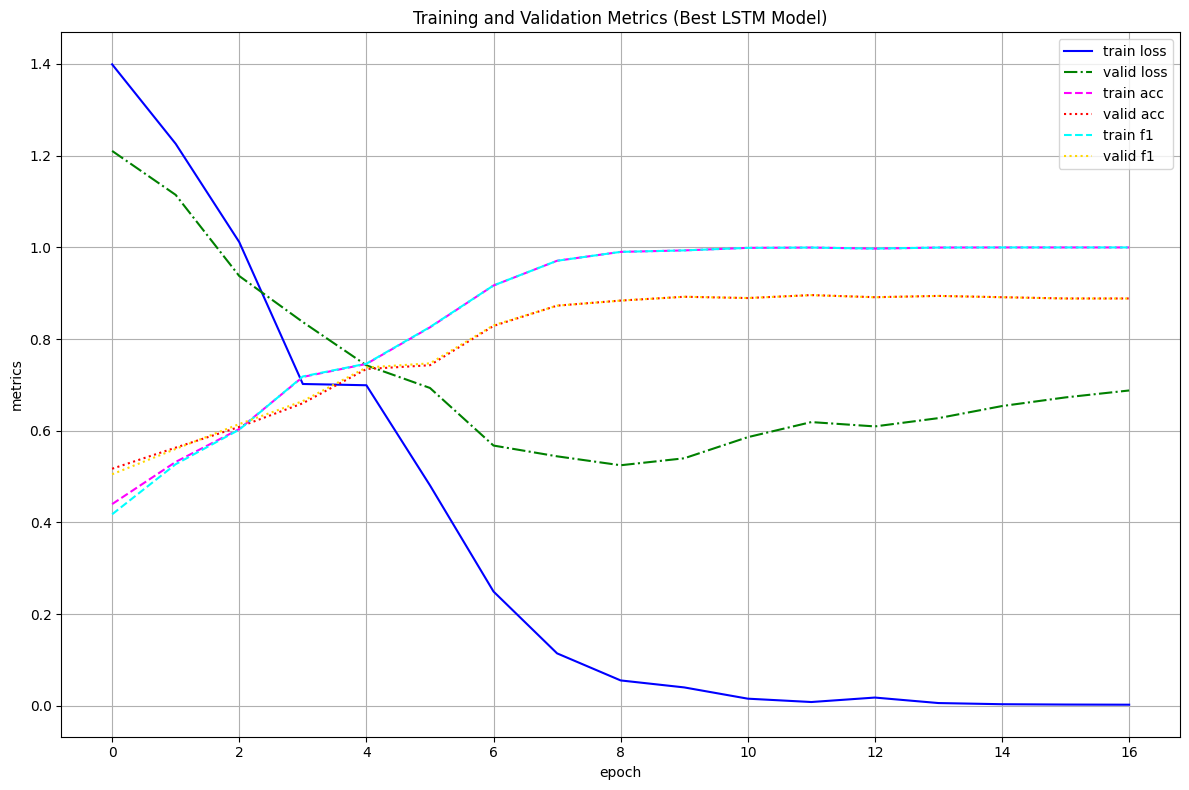

In [20]:
def plot_lstm_learning_curves(net):
    history = net.history

    plt.figure(figsize=(12, 8)) 

    # Plot loss
    plt.plot(history[:, 'train_loss'], label='train loss', color='blue')
    plt.plot(history[:, 'valid_loss'], label='valid loss', color='green', linestyle='-.')
    
    # Plot accuracy
    plt.plot(history[:, 'train_acc'], label='train acc', color='magenta', linestyle='--')
    plt.plot(history[:, 'valid_acc'], label='valid acc', color='red', linestyle=':')
    
    # Plot F1
    plt.plot(history[:, 'train_f1'], label='train f1', color='cyan', linestyle='--')
    plt.plot(history[:, 'valid_f1'], label='valid f1', color='gold', linestyle=':')

    plt.title('Training and Validation Metrics (Best LSTM Model)')
    plt.xlabel('epoch')
    plt.ylabel('metrics')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call this with the best LSTM model found
plot_lstm_learning_curves(search.best_estimator_)

In GridSearch, we configured max_epoch=20. However, the best params found stopped at epoch=16 due to early stop as weighted_f1 has not improved in the last 5 epoch. From the chart, we can see signs of overfitting for epoch 10 onwards as all metrics plateau. 

At epoch 8, model has reached a good balance point. Training loss has decreased significantly from start value and validation metrics have mostly plateaued. Both accuracy and weighted f1 for training and validation remain reasonably aligned. Hence, we will stop training the model at epoch=8. 

### Train LSTM with Best Params

In [27]:
best_net.set_params(max_epochs=8)  #set to prevent overfit 
best_net.fit(X_train, y_train) #retrain on full set - test is now the hold out test set

# Evaluate
preds = best_net.predict(X_test)
probs = best_net.predict_proba(X_test)

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='weighted')
report = classification_report(y_test, preds, target_names=label_encoder.classes_, digits=4)

print(f"LSTM Accuracy (Synthetic) (epoch 8): {acc * 100:.2f}%")
print(f"LSTM Weighted F1-score (Synthetic) (epoch 8): {f1:.4f}")
print("\nClassification Report (Synthetic) (epoch 8):\n", report)

Re-initializing module because the following parameters were re-set: bidirectional, dropout, embedding_tensor, hidden_dim, num_layers.
Re-initializing criterion.
Re-initializing optimizer.


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr      dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  -------
      1       0.4429      0.4317        1.3773       0.4793      0.4618        1.2205  0.0010  16.4322
      2       0.5806      0.5783        1.1024       0.5945      0.5827        0.8877  0.0010  16.5368
      3       0.7037      0.7030        0.7993       0.6101      0.5945        0.8926  0.0010  16.4827
      4       0.7750      0.7753        0.6139       0.7382      0.7400        0.6581  0.0010  16.4337
      5       0.8252      0.8253        0.4589       0.7622      0.7656        0.6410  0.0010  16.5637
      6       0.8573      0.8574        0.3820       0.7567      0.7595        0.6613  0.0010  16.7336
      7       0.9119      0.9119        0.2528       0.8046      0.8089        0.5603  0.0010  16.7253
      8       0.9583      0.9583        0.1297       0.8599      0.8611  

## Evaluation

In [35]:
y_pred = best_net.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4)

print(f"LSTM Accuracy (Synthetic): {acc * 100:.2f}%")
print(f"LSTM Weighted F1-score (Synthetic): {f1:.4f}")
print("\nClassification Report (Synthetic):\n", report)

LSTM Accuracy (Synthetic): 73.68%
LSTM Weighted F1-score (Synthetic): 0.7444

Classification Report (Synthetic):
               precision    recall  f1-score   support

      center     0.4265    0.7073    0.5321        41
   lean left     0.7593    0.6721    0.7130        61
  lean right     0.7000    0.5676    0.6269        37
        left     0.8786    0.8153    0.8458       222
       right     0.6329    0.6579    0.6452        76

    accuracy                         0.7368       437
   macro avg     0.6795    0.6840    0.6726       437
weighted avg     0.7617    0.7368    0.7444       437



### Classification Report Commentary 

Accuracy rose from 0.6651 to 0.7368 while weighted F1 rose from 0.6708 to 0.7444. While the improvements were not as dramatic as the first round, we anticipated the jump to be lower than the first augmentation as there is diminishing returns expected with the addition of more data. 

### Confusion Matrices

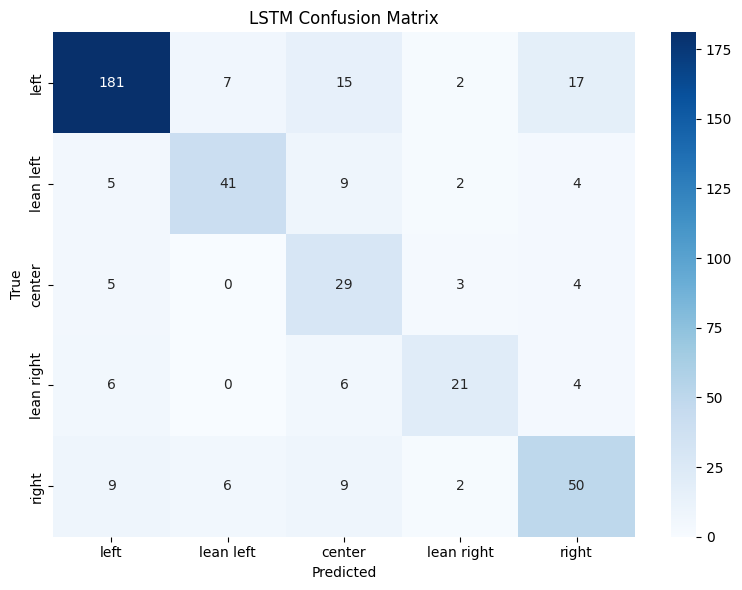

In [29]:
X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()
y_pred = best_net.predict(X_test_np)

# Define correct label order
label_order = ['left', 'lean left', 'center', 'lean right', 'right']
label_indices = [np.where(label_encoder.classes_ == label)[0][0] for label in label_order]

cm = confusion_matrix(y_test_np, y_pred, labels=label_indices)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_order, yticklabels=label_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LSTM Confusion Matrix')
plt.tight_layout()
plt.show()

Marked improvement over the augmented and original confusion matrixes are notied. There is a clear result in the diagonal. 

In [30]:
classes = best_net.classes_
class_names = label_encoder.classes_

for i, class_idx in enumerate(classes):
    class_label = class_names[class_idx]
    
    y_true_binary = (y_test_np == class_idx).astype(int)
    y_pred_binary = (y_pred == class_idx).astype(int)

    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print(f"\nOne-vs-Rest Confusion Matrix for class '{class_label}':")
    print(cm)


One-vs-Rest Confusion Matrix for class 'center':
[[357  39]
 [ 12  29]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[363  13]
 [ 20  41]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[391   9]
 [ 16  21]]

One-vs-Rest Confusion Matrix for class 'left':
[[190  25]
 [ 41 181]]

One-vs-Rest Confusion Matrix for class 'right':
[[332  29]
 [ 26  50]]


## ROC-AUC

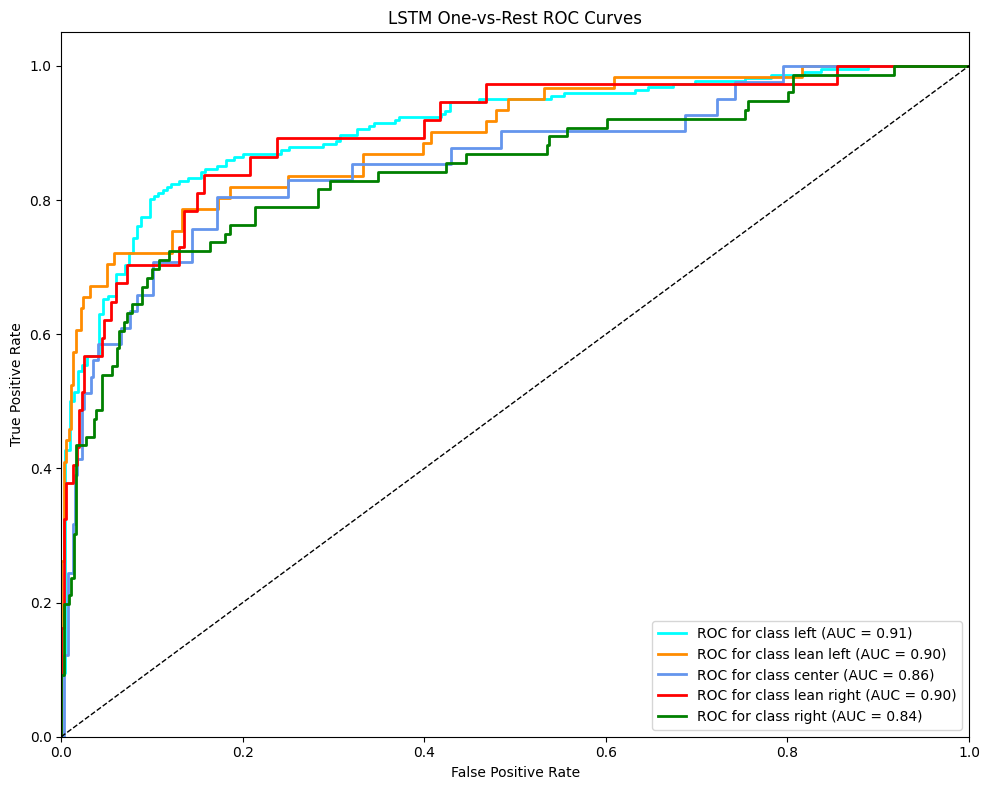

In [31]:
label_order = ['left', 'lean left', 'center', 'lean right', 'right']
label_indices = [np.where(label_encoder.classes_ == label)[0][0] for label in label_order]

X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()
classes = best_net.classes_
class_names = label_encoder.classes_

y_test_binarized = label_binarize(y_test_np, classes=range(len(classes)))
y_score = best_net.predict_proba(X_test_np)

fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute ROC data
for label, idx in zip(label_order, label_indices):
    fpr[label], tpr[label], _ = roc_curve(y_test_binarized[:, idx], y_score[:, idx])
    roc_auc[label] = roc_auc_score(y_test_binarized[:, idx], y_score[:, idx])

# Plot
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])

for label, color in zip(label_order, colors):
    plt.plot(fpr[label], tpr[label], color=color, lw=2,
             label=f'ROC for class {label} (AUC = {roc_auc[label]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM One-vs-Rest ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [32]:
macro_auc = roc_auc_score(y_test_binarized, y_score, average='weighted')
print(f"Macro-average ROC AUC: {macro_auc:.4f}")

Macro-average ROC AUC: 0.8893


Macro average ROC-AUC lifted marginally from 0.8714 to 0.8893 and the pattern of the ROC-AUC curves are comparable. 

## Final Conclusion 

### Key Observations 

<img src="images/LSTM_perf_syn.png" width="700">

Accuracy rose from 0.6651 to 0.7368, while weighted F1 improved from 0.6708 to 0.7444 with the introduction of synthetic data. While these gains were not as pronounced as in the first augmentation phase, this aligns with our expectations—data augmentation often yields diminishing returns as the model saturates its capacity to benefit from additional training examples.

The improvements demonstrate that synthetic data helped the model generalize better, particularly on underrepresented classes. This suggests that even artificially generated samples can provide meaningful signals for learning decision boundaries, especially when real data is limited or imbalanced. Notably, the weighted F1 increase indicates better performance across class distributions, rather than improvements limited to majority classes.

Going forward, it might be more useful to focus on improving the quality of the synthetic data rather than only generating more of it so as to prevent overfitting ot synthetic patterns or noise. 

For example, using more controlled generation (e.g., class-conditional templates, prompt engineering, or filtering out low-quality outputs) could help.